# 03. Hyperparameter Optimization Test

This notebook develops a neural network using a complete hyperparameter optimization and feature ablation.

Rather than selecting training parameters manually, each important hyperparameter is optimized independently using the validation dataset.

Only one parameter is varied at a time while all remaining parameters are held constant. Once the optimal value has been identified, it is fixed before progressing to the next optimization stage.

This process reduces unnecessary experimentation, produces a more reproducible methodology, and provides clear evidence for the final model configuration presented in this project.

Following optimization, the final neural network is trained using the selected parameters before being evaluated on the completely unseen 2025 Formula One season.

# Import Required Libraries

Import the libraries required to build, train, and evaluate the neural network.

In [2]:
#Importing Libraries for data processing and collection from previous notebook

import numpy as np

import pandas as pd

from matplotlib import pyplot as plt

import seaborn as sns

import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer

#Importing Libraries for the neural network

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.layers import Input

#Import Accuracy Metrics

from sklearn.metrics import f1_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Load Processed Data

Load the processed training and validation datasets generated in the previous notebook.

Since all preprocessing has already been completed, the data can now be passed directly into the neural network.

In [3]:
#Import processed data

X_train = np.load("../../data/processed/X_train.npy")
X_val = np.load("../../data/processed/X_val.npy")

y_train = np.load("../../data/processed/y_train.npy")
y_val = np.load("../../data/processed/y_val.npy")

preprocessor = joblib.load("../../models/preprocessor.pkl")

numerical_features = joblib.load(
    "../../data/processed/numerical_features.pkl"
)

categorical_features = joblib.load(
    "../../data/processed/categorical_features.pkl"
)

train_df = joblib.load("../../data/processed/train_df.pkl")
val_df = joblib.load("../../data/processed/val_df.pkl")
test_df = joblib.load("../../data/processed/test_df.pkl")

ValueError: Object arrays cannot be loaded when allow_pickle=False

# Build Neural Network

To simplify experimentation, the neural network architecture is defined as a reusable function.

This allows different hyperparameter combinations to be evaluated without rewriting the model for every experiment, improving both readability and reproducibility.

In [50]:
def build_model(

    input_dim,

    learning_rate=0.001,

    dropout_rate=0.30,

    gamma=2.0,

    alpha=0.25

):

    model = Sequential([

        Input(shape=(input_dim,)),

        Dense(128),

        BatchNormalization(),

        tf.keras.layers.ReLU(),

        Dropout(dropout_rate),

        Dense(64),

        BatchNormalization(),

        tf.keras.layers.ReLU(),

        Dropout(dropout_rate),

        Dense(32),

        BatchNormalization(),

        tf.keras.layers.ReLU(),

        Dense(1, activation="sigmoid")

    ])


    optimizer = tf.keras.optimizers.Adam(

        learning_rate=learning_rate

    )


    loss = tf.keras.losses.BinaryFocalCrossentropy(

        gamma=gamma,

        alpha=alpha

    )


    model.compile(

        optimizer=optimizer,

        loss=loss,

        metrics=["accuracy"]

    )

    return model

# Shared Training Configuration

Each experiment uses the same callback strategy to improve training stability.

Early stopping prevents unnecessary training once validation performance stops improving, while an adaptive learning rate allows the optimizer to make progressively smaller updates as convergence is approached.

A fresh set of callbacks is created for every experiment to prevent internal callback states from being shared between different models during hyperparameter optimization.

In [51]:
def get_callbacks():

    #EarlyStopping (stops training automatically when the model stops improving)
    #use a patience value of 15-30 as the class imbalance is going to create a lot of fluctuation in val loss... we have restore_best_weights as well so we should be fine!

    early_stop = EarlyStopping(

    monitor="val_loss",

    patience=12,

    restore_best_weights=True,

    verbose=1

    )

    #Reducing the learning rate if performance plateaus
    reduce_lr = ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=8,

        cooldown=3,

        min_lr=1e-6,

        verbose=1

    )

    return [

        early_stop,

        reduce_lr

    ]

# Model Evaluation Functions

Rather than rewriting the complete training procedure for every optimisation stage, a single reusable function is used.

This function trains a neural network using a supplied collection of hyperparameters before evaluating performance on the validation dataset.

The optimal decision threshold is determined automatically by maximising the F1-score of the pit-stop class.

In [52]:
def evaluate_configuration(

    X_train,

    y_train,

    X_val,

    y_val,

    epochs,

    class_weight=12,

    learning_rate=0.001,

    dropout=0.3,

    gamma=2,

    alpha=0.25,

    batch_size=64,

    threshold=0.50,

    return_model=True

):

    #Get callbacks
    early_stop, reduce_lr = get_callbacks()

    #Build model
    model = build_model(

    X_train.shape[1],

    learning_rate,

    dropout,

    gamma,

    alpha

    )

    #Train
    history = model.fit(

    X_train,

    y_train,

    validation_data=(X_val,y_val),

    epochs=epochs, #will be 60 epochs for optimization stages, will be 100-150 for the final test data eval.

    batch_size=batch_size,

    verbose=0,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    class_weight={

        0:1,

        1:class_weight

    }

    )

    #Save epoch value
    epochs_trained = len(history.history["loss"])

    #Validation predictions
    probabilities = model.predict(

    X_val,

    verbose=0

    ).flatten()


    prediction = (

        probabilities >= threshold #use default for now

    ).astype(int)


    #Return results
    results = {

        "Epochs": epochs_trained,

        "Precision":precision_score(

            y_val,

            prediction

        ),

        "Recall":recall_score(

            y_val,

            prediction

        ),

        "F1":f1_score(

            y_val,

            prediction

        )

    }

    if return_model:

        results["Model"] = model

        results["History"] = history

    return results

### Shared Plotting Function

The following helper function is used throughout each optimisation stage to visualise model performance and simplify comparison between experiments.

In [53]:
def plot_metric(

    dataframe,

    parameter,

    metric,

    title

):

    plt.figure(figsize=(8,5))

    plt.plot(

        dataframe[parameter],

        dataframe[metric],

        marker="o"

    )

    plt.grid(alpha=0.3)

    plt.xlabel(parameter)

    plt.ylabel(metric)

    plt.title(title)

    plt.show()

# Feature Group Ablation Study

Throughout data preparation, a large number of variables were engineered to describe different aspects of a driver's race.

These features naturally fall into several groups, including tyre behaviour, lap-time performance, race progression, position changes, degradation trends, and race-specific information.

Rather than investigating every individual feature separately, an ablation study was performed by removing one complete feature group at a time.

This makes it possible to determine which types of information contribute the most towards predicting pit-stop decisions.

Each experiment was evaluated using the validation dataset, with the pit-stop F1-score used as the primary performance metric.

The best-performing feature groups were retained throughout the remainder of the optimisation process.

In [54]:
#Helper function

def evaluate_feature_group(
    removed_features,
    group_name
):
    """
    Removes a feature group,
    rebuilds the preprocessing,
    trains the model,
    and returns validation metrics.
    """

    current_numeric = [
        f for f in numerical_features
        if f not in removed_features
    ]

    current_categorical = [
        f for f in categorical_features
        if f not in removed_features
    ]

    feature_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                current_numeric
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore", sparse_output=False
                ),
                current_categorical
            )
        ]
    )

    X_train_temp = feature_preprocessor.fit_transform(
        train_df.drop("PitNextLap", axis=1)
    )

    X_val_temp = feature_preprocessor.transform(
        val_df.drop("PitNextLap", axis=1)
    )

    y_train_temp = train_df["PitNextLap"].values
    y_val_temp = val_df["PitNextLap"].values

    results = {'Removed_Group': group_name}

    results.update(evaluate_configuration(X_train_temp, y_train_temp, X_val_temp, y_val_temp, epochs=60, return_model=False))

    return results

### Baseline Model

Before removing any feature groups, the current best-performing neural network was first evaluated using the complete feature set.

This provides a reference point against which every subsequent ablation experiment can be compared.

In [55]:
baseline = evaluate_configuration(

    X_train,

    y_train,

    X_val,

    y_val,

    epochs=60,

    class_weight=6,

    learning_rate=0.001,

    dropout=0.3,

    gamma=2,

    alpha=0.25,

    batch_size=64,

    return_model=False

)

baseline


Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 8.


{'Epochs': 20,
 'Precision': 0.44002695417789756,
 'Recall': 0.8660477453580901,
 'F1': 0.5835567470956211}

In [56]:
#Divide features into groups

feature_groups = {

    "Tyre Features":[

        "TyreLife",

        "Prev_TyreLife",

        "TyreLifeSquared",

        "TyreWearRate",

        "Compound",

        "Stint"

    ],

    "Lap Time Features":[

        "LapTime (s)",

        "LapTime_Delta",

        "RollingLapTime3",

        "RollingLapTime5",

        "RollingLapStd3",

        "RollingLapStd5",

        "RollingDelta3",

        "RollingDelta5",

        "LapNumber",

        "Cumulative_Degradation",

        "RollingDeg3",

        "RollingDeg5",

        "RollingDegStd3",

        "RollingDegStd5"

    ],

    "Race State":[

        "RaceProgress",

        "Position",

        "Position_Change"

    ],

    "Race Identity":[

        "Race"

    ],

    "Driver Features":[

        "Driver"

    ]

}

In [ ]:
#Run removal tests on each feature group

results=[]

for group,features in feature_groups.items():

    print(f"Removing {group}")

    output = evaluate_feature_group(
        features,
        group
    )

    results.append(output)

In [58]:
#Create Result Table

results=pd.DataFrame(results)

results["Baseline F1"] = baseline["F1"]

results["ΔF1"] = (
    results["F1"] -
    baseline["F1"]
)

results=results.sort_values(
    "ΔF1",
    ascending=False
)

results

,Removed_Group,Epochs,Precision,Recall,F1,Baseline F1,ΔF1
4,Driver Features,26,0.378865,0.893899,0.532175,0.583557,-0.051381
3,Race Identity,30,0.375561,0.888594,0.527975,0.583557,-0.055582
2,Race State,17,0.355805,0.881963,0.507053,0.583557,-0.076504
0,Tyre Features,29,0.311745,0.855438,0.456961,0.583557,-0.126596
1,Lap Time Features,13,0.080857,0.440318,0.136626,0.583557,-0.446931


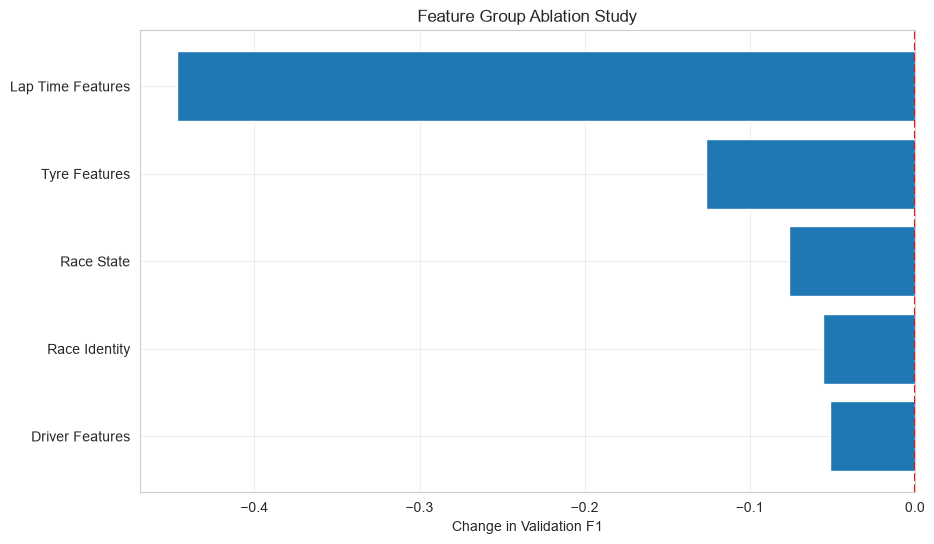

<Figure size 640x480 with 0 Axes>

In [60]:
#Plot

plt.figure(figsize=(10,6))

plt.barh(

    results["Removed_Group"],

    results["ΔF1"]

)

plt.axvline(
    0,
    linestyle="--",
    color="red"
)

plt.xlabel("Change in Validation F1")

plt.title(
    "Feature Group Ablation Study"
)

plt.grid(alpha=0.3)

plt.show()

#Save graph to figure folder
plt.savefig("../../figures/feature_group_ablation_plot.png")

The largest reduction in validation F1-score occurred when the Lap Time Features were removed, demonstrating that recent lap-time performance and degradation trends contained the strongest predictive information for pit-stop decisions.

Interestingly, removing the Driver feature slightly improved performance. This suggests that the network may have been learning driver-specific tendencies that did not generalise well to unseen races. Consequently, the Driver feature was removed from the final model.

The study also showed that removing Race Identity slightly improved validation performance.

This suggests that the neural network was not gaining much additional predictive information from the raw race name alone, and may have been beginning to learn race-specific patterns that did not generalise particularly well to unseen races.

Although race-specific context is important in Formula One strategy, the Race feature in this dataset appears to be a fairly blunt way of encoding that information. In practice, the model already captures a large amount of the strategic variation through tyre-related variables, lap-time trends, race progression, and degradation features.

For that reason, the Race feature was removed from the final model alongside the Driver feature before continuing with the remaining hyperparameter optimisation.


Overall, the feature ablation study confirmed that the model relied primarily on performance-based indicators rather than memorising race- or driver-specific behaviour, improving confidence in the model's ability to generalise to future races.

In [15]:
#Rebuild preprocessing pipeline

#Remove Driver and Race Identity features

categorical_features.remove("Driver")
categorical_features.remove("Race")

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            numerical_features

        ),

        (

            "cat",

            OneHotEncoder(

                handle_unknown="ignore",

                sparse_output=False

            ),

            categorical_features

        )

    ]

)

In [16]:
#Recreate processed datasets

X_train = preprocessor.fit_transform(

    train_df.drop("PitNextLap", axis=1)

)

X_val = preprocessor.transform(

    val_df.drop("PitNextLap", axis=1)

)

X_test = preprocessor.transform(

    test_df.drop("PitNextLap", axis=1)

)

y_train = train_df["PitNextLap"].values
y_val = val_df["PitNextLap"].values
y_test = test_df["PitNextLap"].values


# Hyperparameter Optimization

### Batch Size Optimisation

The first stage of hyperparameter optimisation investigates the effect of batch size.

Batch size determines how many training samples are processed before the neural network updates its weights. Smaller batch sizes generally provide noisier gradient estimates, which may improve generalisation, whereas larger batch sizes often result in smoother optimisation but can converge towards poorer solutions.

To determine the most suitable batch size for this dataset, several candidate values were evaluated while keeping every other model parameter unchanged.

The validation F1-score was used to identify the optimal batch size before continuing with further hyperparameter optimisation.

In [62]:
batch_sizes = [

    16,
    32,
    64,
    128,
    256

]

batch_results = []

for batch in batch_sizes:

    print(f"Testing batch size = {batch}")

    output = evaluate_configuration(

        X_train = X_train,

        y_train = y_train,

        X_val = X_val,

        y_val = y_val,

        epochs = 60,

        learning_rate = 0.001,

        dropout = 0.30,

        gamma = 2,

        alpha = 0.25,

        class_weight = 6, #Keep all other vars default except batch

        batch_size = batch

    )

    output["Batch Size"] = batch

    batch_results.append({

            "Batch Size":output["Batch Size"],

            "Epochs":output["Epochs"],

            "Precision":output["Precision"],

            "Recall":output["Recall"],

            "F1":output["F1"]

        })

batch_results = pd.DataFrame(batch_results)

Testing batch size = 16

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 4.
Testing batch size = 32

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 6.
Testing batch size = 64

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 13.
Testing batch size = 128

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 10.
Testing batch size = 256

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 24.


In [63]:
#Display results

display(batch_results)

,Batch Size,Epochs,Precision,Recall,F1
0,16,16,0.431593,0.866048,0.576092
1,32,18,0.407895,0.863395,0.554043
2,64,25,0.500766,0.867374,0.634951
3,128,22,0.402120,0.855438,0.547074
4,256,36,0.432131,0.874005,0.578324


In [64]:
#Print best batch size

best_batch_size = batch_results.loc[

    batch_results["F1"].idxmax(),

    "Batch Size"

]

print(best_batch_size)

64


In [65]:
#Save

#Save results

batch_results.to_csv(

    "../results/batch_size_results_ARCHIVED.csv",

    index=False

)

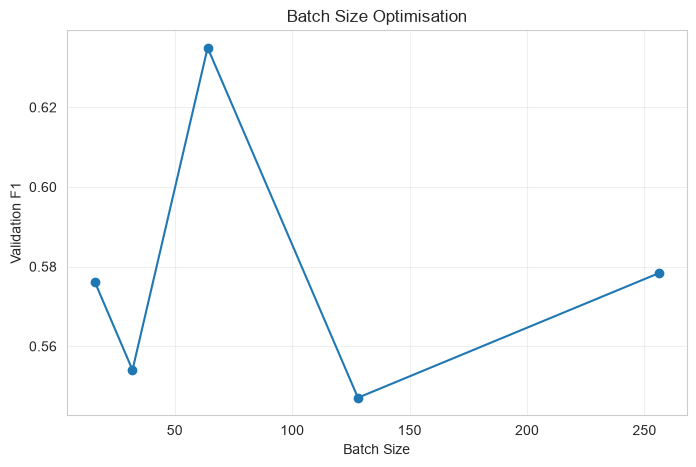

In [66]:
#Plot

plt.figure(figsize=(8,5))

plt.plot(

    batch_results["Batch Size"],

    batch_results["F1"],

    marker="o"

)

plt.xlabel("Batch Size")

plt.ylabel("Validation F1")

plt.title("Batch Size Optimisation")

plt.grid(alpha=0.3)

plt.show()

### Learning Rate Optimisation

The learning rate controls the magnitude of each optimisation step performed by the Adam optimiser.

Learning rates that are too large may prevent convergence, whereas excessively small learning rates can substantially increase training time or result in premature convergence.

Several candidate learning rates are therefore evaluated while holding all remaining parameters constant.

In [68]:
#Load batch size results to avoid re-running code

batch_results = pd.read_csv(
    "../../results/batch_size_results_ARCHIVED.csv"
)

best_batch_size = int(

    batch_results.loc[

        batch_results["F1"].idxmax(),

        "Batch Size"

    ]

)

print(best_batch_size)



64


In [70]:
learning_rates = [

    0.0001,

    0.0003,

    0.0005,

    0.001,

    0.003

]

results = []

for lr in learning_rates:

    print(lr)

    output = evaluate_configuration(

        X_train = X_train,

        y_train = y_train,

        X_val = X_val,

        y_val = y_val,

        epochs = 60,

        class_weight=6,

        learning_rate=lr,

        dropout=0.30,

        gamma=2,

        alpha=0.25,

        batch_size=best_batch_size,

    )

    results.append({

        "Learning Rate":lr,

        "Epochs":output["Epochs"],

        "Precision":output["Precision"],

        "Recall":output["Recall"],

        "F1":output["F1"]

    })

0.0001

Epoch 49: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 41.
0.0003

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 22.
0.0005

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 16.
0.001

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 8.
0.003

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 7.


In [71]:
#Display results
learning_rate_results = pd.DataFrame(results)

learning_rate_results

,Learning Rate,Epochs,Precision,Recall,F1
0,0.0001,53,0.364083,0.884615,0.515855
1,0.0003,34,0.393724,0.881963,0.544413
2,0.0005,28,0.434150,0.870027,0.579249
3,0.0010,20,0.431759,0.872679,0.577700
4,0.0030,19,0.473493,0.864721,0.611919


In [72]:
#Save results
learning_rate_results.to_csv(

    "../results/learning_rate_results_ARCHIVED.csv",

    index=False

)

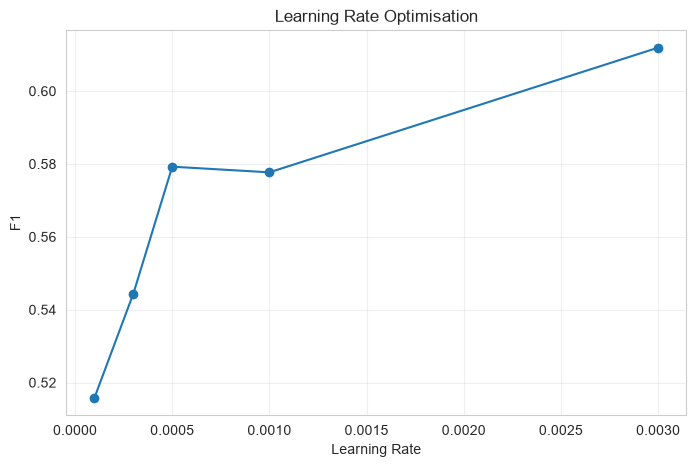

In [73]:
#Plot results
plot_metric(

    learning_rate_results,

    "Learning Rate",

    "F1",

    "Learning Rate Optimisation"

)

In [20]:
best_learning_rate = learning_rate_results.sort_values(

    "F1",

    ascending=False

).iloc[0]["Learning Rate"]

print(best_learning_rate)

0.0003


The selected learning rate is fixed before proceeding to dropout optimisation.

### Dropout Optimisation

Dropout is used to reduce overfitting by randomly disabling a proportion of neurons during training.

Several dropout rates are investigated to determine the best compromise between model generalisation and predictive performance.

In [74]:
#Load saved best learning rate

learning_rate_results = pd.read_csv(
    "../../results/learning_rate_results_ARCHIVED.csv"
)

best_learning_rate = float(

    learning_rate_results.loc[

        learning_rate_results["F1"].idxmax(),

        "Learning Rate"

    ]

)

print(best_learning_rate)

0.003


In [75]:
dropouts = [

    0.20,

    0.25,

    0.30,

    0.35,

    0.40

]

results = []

for dropout in dropouts:

    print(dropout)

    output = evaluate_configuration(

        X_train = X_train,

        y_train = y_train,

        X_val = X_val,

        y_val = y_val,

        epochs = 60,

        class_weight=6,

        learning_rate=best_learning_rate,

        dropout=dropout,

        gamma=2,

        alpha=0.25,

        batch_size=best_batch_size

    )

    results.append({

        "Dropout":dropout,

        "Epochs":output["Epochs"],

        "Precision":output["Precision"],

        "Recall":output["Recall"],

        "F1":output["F1"]

    })

0.2

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 6.
0.25

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 5.
0.3

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 16.
0.35

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 8.
0.4

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 3.


In [76]:
#Display results

dropout_results = pd.DataFrame(results)

dropout_results

,Dropout,Epochs,Precision,Recall,F1
0,0.20,18,0.509944,0.850133,0.637494
1,0.25,17,0.441974,0.843501,0.580027
2,0.30,28,0.467849,0.839523,0.600854
3,0.35,20,0.543814,0.839523,0.660063
4,0.40,15,0.514310,0.786472,0.621919


In [77]:
#Save results

dropout_results.to_csv(

    "../results/dropout_results_ARCHIVED.csv",

    index=False

)

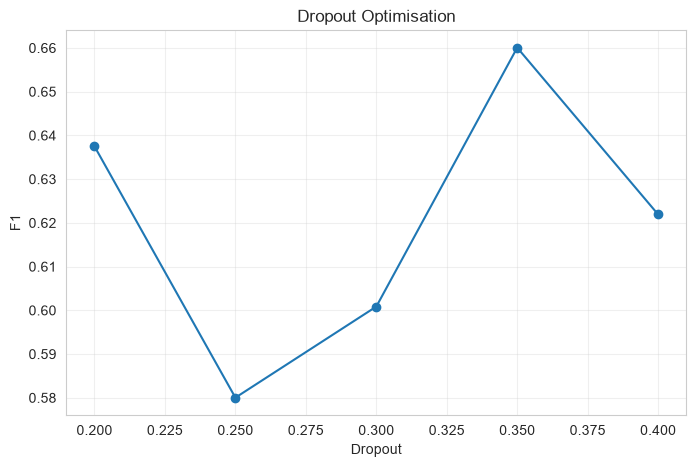

In [78]:
#Plot results

plot_metric(

    dropout_results,

    "Dropout",

    "F1",

    "Dropout Optimisation"

)

In [79]:
best_dropout = dropout_results.sort_values(

    "F1",

    ascending=False

).iloc[0]["Dropout"]

print(best_dropout)

0.35


The optimal dropout rate is retained throughout the remaining optimisation stages.

### Binary Focal Loss Optimisation

Binary Focal Cross-Entropy introduces two additional parameters.

The focusing parameter (γ) determines the degree to which easily classified observations contribute to the loss function.

The balancing parameter (α) adjusts the contribution of the minority class.

Both parameters are optimised simultaneously to maximise pit-stop prediction performance.

In [80]:
#Load saved dropout rate

dropout_results = pd.read_csv(
    "../../results/dropout_results_ARCHIVED.csv"
)

best_dropout = float(

    dropout_results.loc[

        dropout_results["F1"].idxmax(),

        "Dropout"

    ]

)

print(best_dropout)


0.35


In [81]:
gammas = [

    1,

    2,

    3,

    4

]

alphas = [

    0.2,0.3,0.4,0.5,0.6,0.7,0.8

]

results = []

for gamma in gammas:

    for alpha in alphas:

        print(gamma, alpha)

        output = evaluate_configuration(

            X_train = X_train,

            y_train = y_train,

            X_val = X_val,

            y_val = y_val,

            epochs = 60,

            class_weight=6,

            learning_rate=0.001,

            dropout=0.30,

            gamma=gamma,

            alpha=alpha,

            batch_size=best_batch_size

        )

        results.append({

            "Gamma":gamma,

            "Alpha":alpha,

            "Epochs":output["Epochs"],

            "Precision":output["Precision"],

            "Recall":output["Recall"],

            "F1":output["F1"]

        })

1 0.2

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 10.
1 0.3

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 9.
1 0.4

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 7.
1 0.5

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 14.
1 0.6

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 10.
1 0.7

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487

In [82]:
#Display results

focal_results = pd.DataFrame(results)

focal_results.sort_values(

    "F1",

    ascending=False

)

,Gamma,Alpha,Epochs,Precision,Recall,F1
20,3,0.8,29,0.479735,0.863395,0.616769
4,1,0.6,22,0.455722,0.887268,0.602160
5,1,0.7,18,0.472561,0.822281,0.600194
16,3,0.4,24,0.464338,0.846154,0.599624
12,2,0.7,22,0.461318,0.854111,0.599070
17,3,0.5,21,0.453911,0.862069,0.594694
6,1,0.8,21,0.451748,0.856764,0.591575
26,4,0.7,20,0.455213,0.822281,0.586011
27,4,0.8,28,0.444674,0.858090,0.585785
1,1,0.3,21,0.440940,0.871353,0.585561


In [83]:
#Save results

focal_results.to_csv(

    "../results/focal_loss_results_ARCHIVED.csv",

    index=False

)

In [84]:
best_row = focal_results.sort_values(

    "F1",

    ascending=False

).iloc[0]

best_gamma = best_row["Gamma"]

best_alpha = best_row["Alpha"]

print(best_gamma, best_alpha)

3.0 0.8


### Class Weight Optimisation

The dataset used throughout this project is highly imbalanced, with pit stops representing only a small proportion of the total observations.

Without compensation, the neural network naturally favours the majority "No Pit" class, resulting in poor identification of pit-stop laps.

To address this issue, several class weight combinations are evaluated while keeping every remaining training parameter constant.

The optimal weighting is selected according to the F1-score of the pit-stop class measured on the validation dataset.

In [85]:
#Load focal loss results to avoid re-running code

focal_results = pd.read_csv(
    "../../results/focal_loss_results_ARCHIVED.csv"
)

best_row = focal_results.loc[
    focal_results["F1"].idxmax()
]

best_gamma = float(best_row["Gamma"])

best_alpha = float(best_row["Alpha"])

print(best_gamma)
print(best_alpha)

3.0
0.8


In [86]:
#Check class balances

print(pd.Series(y_train).value_counts())

print(pd.Series(y_train).value_counts(normalize=True))

0.0    45316
1.0     1458
Name: count, dtype: int64
0.0    0.968829
1.0    0.031171
Name: proportion, dtype: float64


Looks like pit stops are severely underrepresented by a ratio of about 24 rows of data with no pit stops (class 0) for every 1 row with pit stops (class 1)...

Let's see if we can manually test different class weights to get the model working at its optimum!

In [87]:
class_weights = [

    3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20

]

results = []

for weight in class_weights:

    print(f"Testing class weight 1:{weight}")

    output = evaluate_configuration(

        X_train = X_train,

        y_train = y_train,

        X_val = X_val,

        y_val = y_val,

        epochs = 60,

        #ONLY CHANGE CLASS WEIGHT; keeping all other factors constant
        class_weight=weight,

        learning_rate=best_learning_rate,

        dropout=best_dropout,

        gamma=best_gamma,

        alpha=best_alpha,

        batch_size=best_batch_size

    )

    results.append({

        "Class Weight":weight,

        "Epochs":output["Epochs"],

        "Precision":output["Precision"],

        "Recall":output["Recall"],

        "F1":output["F1"]

    })

Testing class weight 1:3

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 14.
Testing class weight 1:4

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 8.
Testing class weight 1:5

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 13.
Testing class weight 1:6

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 15.
Testing class weight 1:7

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 23.
Testing class weight 1:8

Epoch 18: ReduceLROnPlateau reducing lea

In [89]:
#Display results
class_weight_results = pd.DataFrame(results)

class_weight_results

,Class Weight,Epochs,Precision,Recall,F1
0,3,26,0.553134,0.807692,0.656604
1,4,20,0.561644,0.815650,0.665224
2,5,25,0.470036,0.863395,0.608696
3,6,27,0.532095,0.835544,0.650155
4,7,35,0.443383,0.862069,0.585586
5,8,22,0.486070,0.879310,0.626062
6,9,19,0.432359,0.843501,0.571685
7,10,24,0.367760,0.892573,0.520898
8,12,21,0.356632,0.859416,0.504084
9,14,21,0.360255,0.899204,0.514416


In [90]:
#Save result table
class_weight_results.to_csv(

    "../results/class_weight_results.csv",

    index=False

)

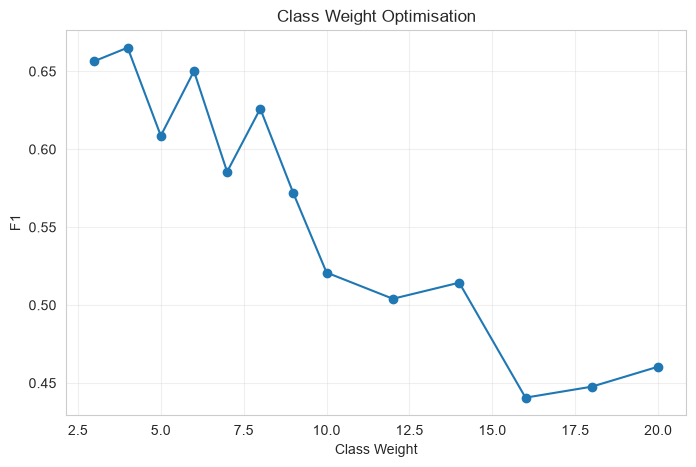

In [91]:
#Plot results
plot_metric(

    class_weight_results,

    "Class Weight",

    "F1",

    "Class Weight Optimisation"

)

In [92]:
best_weight = class_weight_results.sort_values(

    "F1",

    ascending=False

).iloc[0]["Class Weight"]

print(best_weight)

4.0


In [93]:
#Load saved class weight

class_weight_results = pd.read_csv("../../results/class_weight_results.csv")

best_weight = float(

    class_weight_results.loc[

        class_weight_results["F1"].idxmax(),

        "Class Weight"

    ]

)

print(best_weight)

4.0


The optimal class weighting identified above is retained throughout the remainder of the optimisation process.

All subsequent experiments therefore evaluate only one new hyperparameter at a time while keeping the class weighting fixed.

### Train Final Validation Model

Following completion of hyperparameter optimisation, a single neural network was trained using the optimal configuration identified during the previous experiments.

This model represents the final validation model and is used solely to determine the optimal probability threshold before evaluating performance on the unseen 2025 season.

The model itself is not retrained during threshold optimisation, ensuring that the validation dataset remains the only source used to determine the final decision threshold.

In [94]:
best_results = evaluate_configuration(

    X_train,

    y_train,

    X_val,

    y_val,

    epochs = 60,

    learning_rate=best_learning_rate,

    dropout=best_dropout,

    gamma=best_gamma,

    alpha=best_alpha,

    batch_size=best_batch_size,

    class_weight=best_weight,

    return_model=True

)


Epoch 17: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 9.


In [95]:
best_model = best_results["Model"]

history = best_results["History"]

### Decision Threshold Optimisation

The final stage of model optimisation investigated the decision threshold used to convert predicted probabilities into binary pit-stop decisions.

The neural network outputs a probability between 0 and 1 for every lap. By default, TensorFlow classifies probabilities greater than or equal to 0.50 as a pit stop. However, because pit stops are comparatively rare events, this default threshold is unlikely to provide the best balance between precision and recall.

Rather than retraining the neural network, a range of candidate thresholds was evaluated using the validation dataset. The threshold producing the highest validation F1-score was selected for the final evaluation on the unseen 2025 season.

In [96]:
# Predict probabilities on the validation set

val_probabilities = best_model.predict(

    X_val,

    verbose=0

).flatten()

In [97]:
#Test different threshold values

threshold_results = []

thresholds = np.arange(0.10, 0.96, 0.01)

for threshold in thresholds:

    predictions = (

        val_probabilities >= threshold

    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(y_val, predictions, zero_division=0),

        "Recall": recall_score(y_val, predictions, zero_division=0),

        "F1": f1_score(y_val, predictions, zero_division=0)

    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.sort_values("F1", ascending=False)

,Threshold,Precision,Recall,F1
47,0.57,0.686528,0.702918,0.694626
46,0.56,0.658625,0.724138,0.689829
45,0.55,0.632337,0.757294,0.689197
48,0.58,0.711816,0.655172,0.682320
44,0.54,0.608604,0.769231,0.679555
...,...,...,...,...
81,0.91,0.000000,0.000000,0.000000
82,0.92,0.000000,0.000000,0.000000
83,0.93,0.000000,0.000000,0.000000
84,0.94,0.000000,0.000000,0.000000


In [98]:
#Show best threshold

best_threshold = threshold_results.loc[
    threshold_results["F1"].idxmax(),
    "Threshold"
]

print(f"Best Threshold: {best_threshold:.2f}")

Best Threshold: 0.57


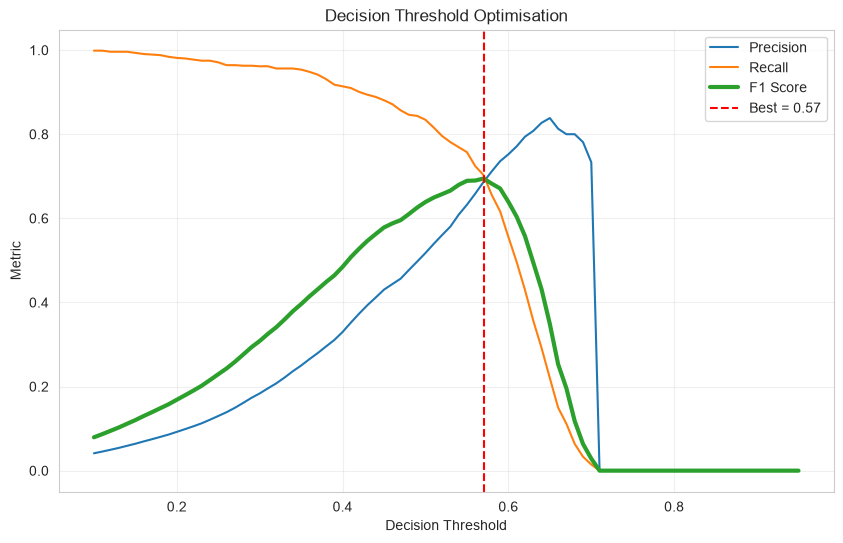

In [99]:
#Plot threshold results

plt.figure(figsize=(10,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    linewidth=3,
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Best = {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric")
plt.title("Decision Threshold Optimisation")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

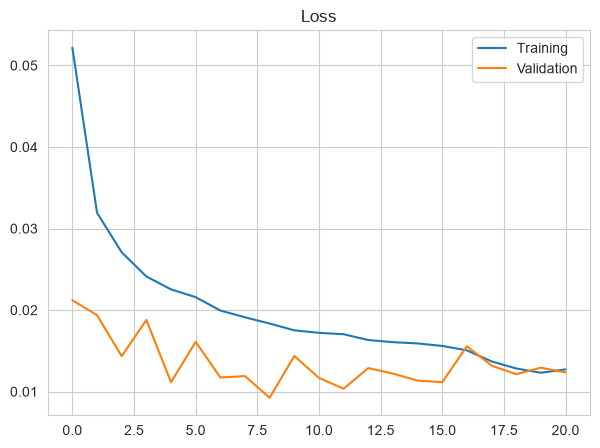

In [100]:
#Plot loss curve

plt.figure(figsize=(7,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Training","Validation"])

plt.title("Loss")

plt.show()

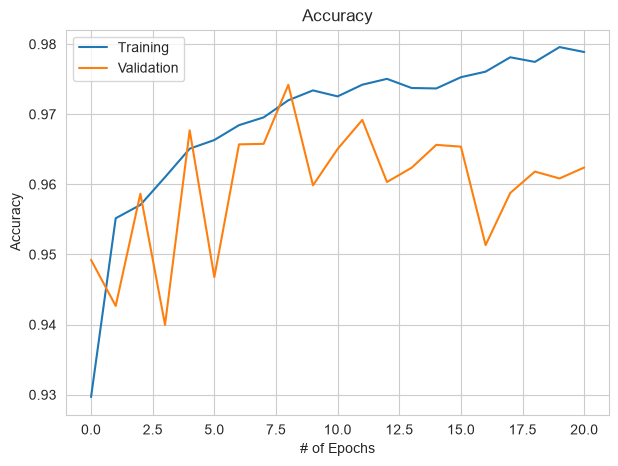

In [101]:
#Plot accuracy curve

plt.figure(figsize=(7,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Training","Validation"])

plt.title("Accuracy")

plt.xlabel("# of Epochs")
plt.ylabel("Accuracy")

plt.show()

# Final Evaluation on the 2025 Formula One Season

Following completion of all optimisation stages, the final neural network was evaluated on the unseen 2025 Formula One season.

No further model training or parameter tuning was performed at this stage. The model architecture, hyperparameters, class weights and decision threshold were fixed using only the training and validation datasets.

Evaluating the model on the unseen 2025 season provides an unbiased assessment of its ability to generalise to future races.

In [102]:
#Create final training data (2022-24) by combining previous training (2022-23) and validation (2024) data

combined_train = pd.concat(

    [

        train_df,

        val_df

    ],

    ignore_index=True

)

In [103]:
#Rebuild the inputs

X_train_final = combined_train.drop(

    "PitNextLap",

    axis=1

)

y_train_final = combined_train["PitNextLap"].values

In [104]:
#Re-fit processor

X_train_final = preprocessor.fit_transform(

    X_train_final

)

X_test_final = preprocessor.transform(

    test_df.drop(

        "PitNextLap",

        axis=1

    )

)

y_test_final = test_df["PitNextLap"].values

In [105]:
#Train the final model

final_results = evaluate_configuration(

    X_train_final,

    y_train_final,

    X_test_final,

    y_test_final,

    epochs = 150,

    learning_rate=best_learning_rate,

    dropout=best_dropout,

    gamma=best_gamma,

    alpha=best_alpha,

    batch_size=best_batch_size,

    class_weight=best_weight,

    threshold=best_threshold,

    return_model=True

)


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 1.


In [106]:
#Extract results

final_model = final_results["Model"]

final_history = final_results["History"]

In [107]:
#Test prediction

test_probabilities = final_model.predict(

    X_test_final,

    verbose=0

).flatten()

test_predictions = (

    test_probabilities >= best_threshold

).astype(int)

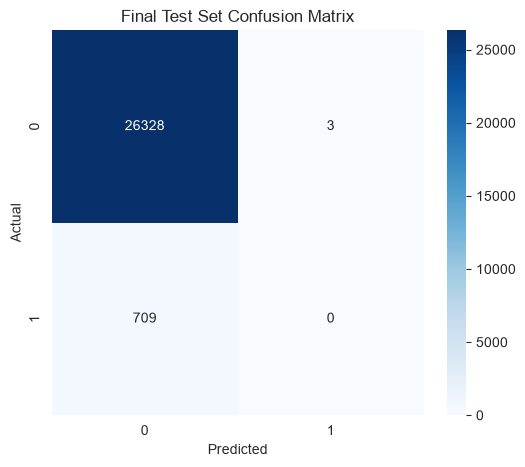

In [108]:
#Confusion Matrix

cm = confusion_matrix(

    y_test_final,

    test_predictions

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Final Test Set Confusion Matrix")

plt.show()

In [109]:
#Classification Report

print(
    classification_report(
        y_test_final,
        test_predictions
    )
)

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99     26331
         1.0       0.00      0.00      0.00       709

    accuracy                           0.97     27040
   macro avg       0.49      0.50      0.49     27040
weighted avg       0.95      0.97      0.96     27040



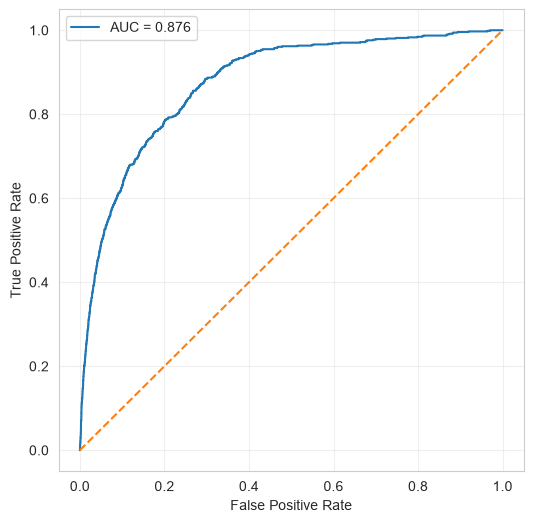

In [110]:
#ROC Curve

fpr, tpr, _ = roc_curve(

    y_test_final,

    test_probabilities

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

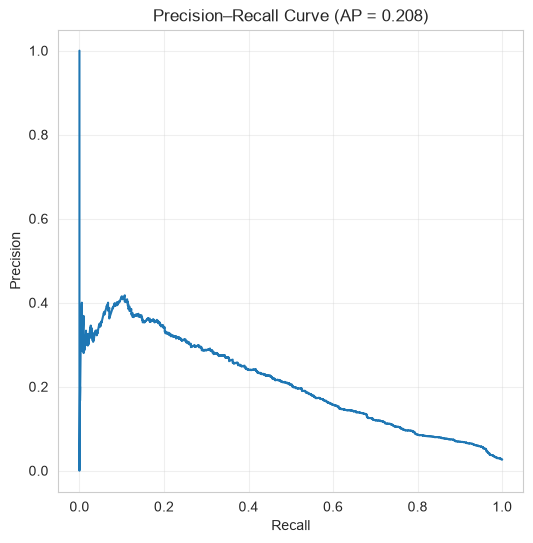

In [111]:
#Precision-Recall Curve
precision, recall, _ = precision_recall_curve(

    y_test_final,

    test_probabilities

)

ap = average_precision_score(

    y_test_final,

    test_probabilities

)

plt.figure(figsize=(6,6))

plt.plot(

    recall,

    precision

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(

    f"Precision–Recall Curve (AP = {ap:.3f})"

)

plt.grid(alpha=0.3)

plt.show()